**Installing dependencies**

In [3]:
!pip install -q langchain langchain-community langchain-groq langchain-qdrant langchain-core
!pip install -q langchain-huggingface sentence-transformers
!pip install -q qdrant-client fastembed
!pip install -q docling pandas python-dotenv requests docling-hierarchical-pdf certifi

### **Setting up Groq for LLM Inference**

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

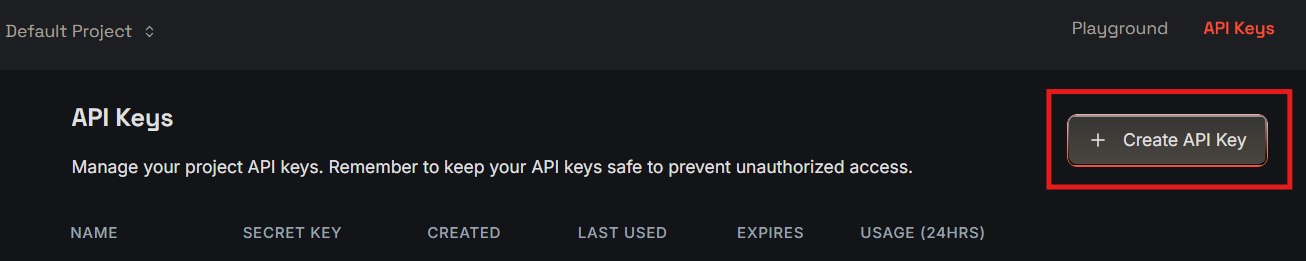

In [4]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

## **Initial Set-up and Chores**

In [5]:
GROQ_MODEL = "openai/gpt-oss-20b"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
COLLECTION_NAME = "telecom_hybrid"

# GitHub raw base URL for all data files
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/main/data"
FAQ_URL      = f"{GITHUB_RAW_BASE}/faq.csv"
PDF_URL      = f"{GITHUB_RAW_BASE}/telecom_guide.pdf"
TICKETS_URL  = f"{GITHUB_RAW_BASE}/tickets.db"

### **Ingesting CSV**



We are going to load the FAQ CSV directly from GitHub.

In [6]:
import pandas as pd
from langchain_core.documents import Document
import certifi
from io import StringIO

import requests

response = requests.get(FAQ_URL, verify=certifi.where())
df = pd.read_csv(StringIO(response.text))
print(f"Loaded {len(df)} FAQ entries")
print(df[["question", "category"]].head())

Loaded 25 FAQ entries
                                        question      category
0        How do I check my current data balance?          data
1             Why is my mobile internet so slow?          data
2          How do I activate 4G/LTE on my phone?  connectivity
3  What should I do if I have no signal at home?  connectivity
4              How do I report a network outage?  connectivity


## **Hybrid RAG: Vector + BM-25**
### **Convert to LangChain Documents**
Each row = one document. The question+answer together form the content.

In [7]:
faq_docs = []
for _, row in df.iterrows():
    content = f"Question: {row['question']}\nAnswer: {row['answer']}"
    doc = Document(
        page_content=content,
        metadata={"source": "faq", "category": row["category"], "id": row["id"]}
    )
    faq_docs.append(doc)

print(f"Created {len(faq_docs)} documents from FAQ")

Created 25 documents from FAQ


In [8]:
print("Sample document:")
print(faq_docs[0].metadata)
print(faq_docs[0].page_content[:200])

Sample document:
{'source': 'faq', 'category': 'data', 'id': 1}
Question: How do I check my current data balance?
Answer: Dial *123# from your mobile or log in to the MyTelecom app and go to My Usage. Your remaining data balance will be shown on the dashboard.


In [9]:
import requests
import tempfile
from docling.document_converter import DocumentConverter
from docling.chunking import HybridChunker
from transformers import AutoTokenizer
from langchain_core.documents import Document

/Users/arokiabhavya/code/AIEngineering/.venv-1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Step 1:** Download the PDF to a temp file (Docling needs a local path)

In [10]:
response = requests.get(PDF_URL)
response.raise_for_status()

with tempfile.NamedTemporaryFile(delete=False, suffix=".pdf") as tmp:
    tmp.write(response.content)
    pdf_path = tmp.name

print(f"Downloaded telecom_guide.pdf → {pdf_path}")


Downloaded telecom_guide.pdf → /var/folders/cv/zm85ty513pn29zxp2p8zsv8m0000gn/T/tmpitx1c2r4.pdf


**Step 2:** Convert PDF → Docling's internal DoclingDocument.

Docling understands layout, tables, headings, and reading order.

In [11]:
converter = DocumentConverter()
dl_doc = converter.convert(pdf_path).document

print("PDF parsed by Docling ✅")

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-13 07:02:14,554 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-13 07:02:14,558 [RapidOCR] download_file.py:60: File exists and is valid: /Users/arokiabhavya/code/AIEngineering/.venv-1/lib/python3.14/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-13 07:02:14,559 [RapidOCR] main.py:65: Using /Users/arokiabhavya/code/AIEngineering/.venv-1/lib/python3.14/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-13 07:02:14,597 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-13 07:02:14,598 [RapidOCR] download_file.py:60: File exists and is valid: /Users/arokiabhavya/code/AIEngineering/.venv-1/lib/python3.14/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_m

PDF parsed by Docling ✅


**Step 3: Chunk with HybridChunker**

We pass the same tokenizer as our embedding model so chunk sizes are calibrated to what the embedder can actually handle (128 tokens)

In [12]:
tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL)

chunker = HybridChunker(
    tokenizer=tokenizer,   # aligns chunk size to the embedding model's token limit
    max_tokens=128,        # max tokens per chunk
    merge_peers=True,      # merge undersized sibling chunks under the same heading
)

chunk_iter = chunker.chunk(dl_doc=dl_doc)

**Step 4:** Convert Docling chunks → LangChain Documents

`chunker.serialize(chunk)` prepends the section heading to each chunk, this gives the embedding model more context than chunk.text alone.


In [13]:
pdf_docs = []
for chunk in chunk_iter:
    pdf_docs.append(Document(
        page_content=chunker.serialize(chunk=chunk),
        metadata={"source": "telecom_guide"}
    ))

print(f"Created {len(pdf_docs)} chunks")
print(f"\nSample chunk (note the heading prepended by serialize()):")
print(pdf_docs[0].page_content[:300])

Created 43 chunks

Sample chunk (note the heading prepended by serialize()):
Telecom Technical Reference Guide
Customer Care & Network Operations Edition
Version 3.2  |  Covers 2G / 3G / 4G LTE / 5G


/var/folders/cv/zm85ty513pn29zxp2p8zsv8m0000gn/T/ipykernel_2097/1528951529.py:4: DeprecationWarning: Use contextualize() instead.
  page_content=chunker.serialize(chunk=chunk),


In [14]:
all_docs = faq_docs + pdf_docs
print(f"Total documents to index: {len(all_docs)}")

Total documents to index: 68


In [15]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import FastEmbedSparse

# Dense embeddings — semantic understanding
dense_embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": "cpu"},      # change to "cuda" if you have a GPU
    encode_kwargs={"normalize_embeddings": True}
)

# Sparse embeddings — BM25 keyword matching (via FastEmbed)
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25", batch_size=32)

print("Dense embedding model:", EMBED_MODEL)
print("Sparse embedding model: Qdrant/BM25")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9388.33it/s]


Dense embedding model: sentence-transformers/all-MiniLM-L6-v2
Sparse embedding model: Qdrant/BM25


In [16]:
from langchain_qdrant import QdrantVectorStore, RetrievalMode

# RetrievalMode.HYBRID stores BOTH dense and sparse vectors
vectorstore = QdrantVectorStore.from_documents(
    documents=all_docs,
    embedding=dense_embeddings,
    sparse_embedding=sparse_embeddings,
    path="/tmp/my_lang_vs",
    collection_name=COLLECTION_NAME,
    retrieval_mode=RetrievalMode.HYBRID,
)

print(f"✅ Indexed {len(all_docs)} documents into Qdrant collection '{COLLECTION_NAME}'")
print("Both dense (semantic) and sparse (BM25) vectors stored.")

✅ Indexed 68 documents into Qdrant collection 'telecom_hybrid'
Both dense (semantic) and sparse (BM25) vectors stored.


In [17]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [18]:
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

# Create a retriever in HYBRID mode
hybrid_retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}       # retrieve top-5 docs
)

# Prompt template
system_prompt = """You are a helpful TelecomCo customer support assistant.
Answer the customer's question using ONLY the information provided in the context below.
If the answer is not in the context, say "I don't have that information."
Keep answers concise and friendly.

Context:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
])

# Build the chain
question_answer_chain = create_stuff_documents_chain(llm, prompt)
hybrid_rag_chain = create_retrieval_chain(hybrid_retriever, question_answer_chain)

print("✅ Hybrid RAG chain ready")

✅ Hybrid RAG chain ready


In [19]:
def ask_hybrid(question: str):
    result = hybrid_rag_chain.invoke({"input": question})
    print(f"Question: {question}")
    print(f"\nAnswer: {result['answer']}")
    print(f"\nSources retrieved:")
    for i, doc in enumerate(result["context"], 1):
        src = doc.metadata.get("source", "unknown")
        cat = doc.metadata.get("category", "")
        print(f"  [{i}] source={src}  category={cat}")
        print(f"Document Content:\n{doc.page_content}")
    print("-" * 60)

# Test queries
ask_hybrid("How do I activate international roaming?")

Question: How do I activate international roaming?

Answer: To activate international roaming, log in to the MyTelecom app, go to **Plan & Services > International Roaming**, and toggle it on at least 24 hours before you travel. You can also enable it by calling 611. Once activated, you’ll need to select a roaming bundle to avoid per‑MB charges. Roaming will automatically turn off when you return home.

Sources retrieved:
  [1] source=telecom_guide  category=
Document Content:
4. International Roaming  - How It Works
Activating Roaming: Roaming must be enabled on the account before departure. The customer can toggle it in the MyTelecom app under Plan & Services > International Roaming or by calling 611. Network-level activation takes up  to  15  minutes.  If  a  customer  enables  roaming  after  landing  abroad,  they  may  receive  a  brief  period  of  no service while the HLR record is updated.
  [2] source=faq  category=roaming
Document Content:
Question: How do I activate interna

In [20]:
# keyword-heavy query
ask_hybrid("Where are APN settings?")

Question: Where are APN settings?

Answer: APN settings are found in your phone’s settings menu: **Settings → Mobile Network → APN**.

Sources retrieved:
  [1] source=telecom_guide  category=
Document Content:
2. Troubleshooting Connectivity Issues
Step 2  - Rule out a temporary network glitch. Toggle airplane mode on for 10 seconds then off. This forces the device to re-register on the network, which resolves many transient issues.
Step 3  - Check APN settings. The Access Point Name (APN) tells the device how to connect to the carrier's data network. Incorrect APN settings are a common cause of data connectivity failure after a phone reset or SIM swap. Navigate to Settings > Mobile Network > APN and verify the APN name, username, and password match the carrier's published settings.
  [2] source=telecom_guide  category=
Document Content:
2. Troubleshooting Connectivity Issues
Step 2  - Rule out a temporary network glitch. Toggle airplane mode on for 10 seconds then off. This forces the

In [21]:
# semantic query
ask_hybrid("My phone shows full bars but I can't load any websites")

Question: My phone shows full bars but I can't load any websites

Answer: It could be a network‑level issue rather than a signal problem.  
- Try toggling airplane mode off and on to force a fresh network reconnect.  
- Check if you’ve reached your high‑speed data cap; once it’s exhausted your speed drops to 512 kbps.  
- If the problem persists, look at the carrier’s live status page or app for a possible outage.  

If you still can’t load sites, you might want to power off, remove the SIM, clean the gold contacts with a dry cloth, and reseat it firmly—sometimes a partially seated SIM can cause intermittent connectivity.

Sources retrieved:
  [1] source=faq  category=data
Document Content:
Question: Why is my mobile internet so slow?
Answer: Slow speeds are usually caused by network congestion in your area, being in a low-signal zone, or reaching your high-speed data cap. Try toggling airplane mode off and on to force a network reconnect. If your high-speed data is exhausted your spee

### **Re-ranking**

Even with Hybrid search, the **initial retrieval is imprecise** — you fetch a broad set (top-10 or top-20) to avoid missing relevant docs. But then you pass all of them to the LLM, which increases:
- **Noise** : irrelevant docs confuse the LLM
- **Token cost** : more context = more tokens
- **Latency** : larger prompts are slower

**Reranking** adds a second, smarter scoring pass *after* initial retrieval to select only the best documents.

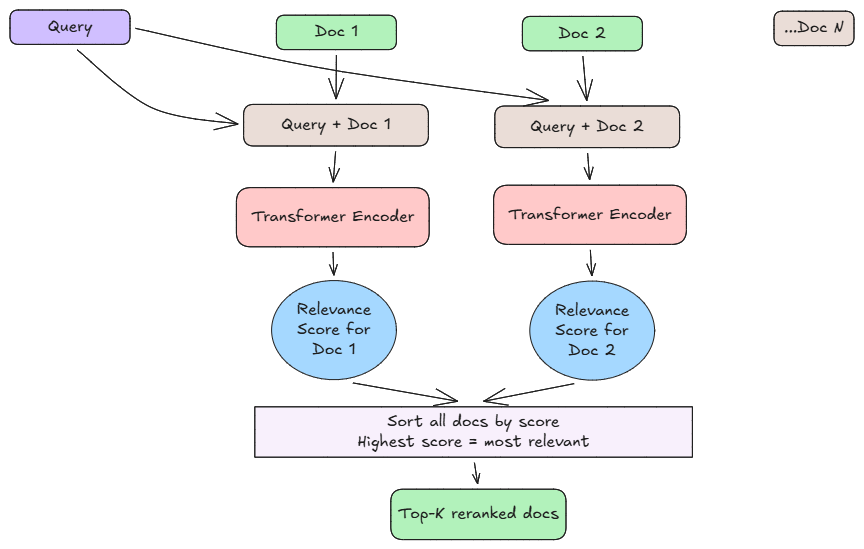

In [22]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# Load cross-encoder model (downloads ~270MB on first run)
cross_encoder = HuggingFaceCrossEncoder(
    model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"
)

# Wrap it as a LangChain document compressor
reranker = CrossEncoderReranker(
    model=cross_encoder,
    top_n=3           # keep only top-3 after reranking
)

print("✅ Cross-encoder reranker ready")
print("Model: cross-encoder/ms-marco-MiniLM-L-6-v2")

/var/folders/cv/zm85ty513pn29zxp2p8zsv8m0000gn/T/ipykernel_2097/2111516817.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7312.61it/s]


✅ Cross-encoder reranker ready
Model: cross-encoder/ms-marco-MiniLM-L-6-v2


First, a broad retriever: fetch more candidates for the reranker to work with.

The `ContextualCompressionsRetriever` is a wrapper for another retriever that iterates over the initial output of the base retriever and filters and compresses those initial documents, so that only the most relevant information is returned.

In [23]:
broad_retriever = vectorstore.as_retriever(
    search_kwargs={"k": 10}    # fetch 10, rerank down to 3
)

reranking_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=broad_retriever
)

print("Retrieval pipeline:")
print("  1. Hybrid search → Top-10 candidates")
print("  2. Cross-encoder reranker → Top-3 best documents")

Retrieval pipeline:
  1. Hybrid search → Top-10 candidates
  2. Cross-encoder reranker → Top-3 best documents


Create the retrieval chain.

In [24]:
reranking_rag_chain = create_retrieval_chain(
    reranking_retriever,
    create_stuff_documents_chain(llm, prompt)
)

print("✅ Hybrid RAG + Reranking chain ready")

✅ Hybrid RAG + Reranking chain ready


Let's see what the cross-encoder scores look like directly

In [26]:
query = "How do I check my data balance?"
candidates = broad_retriever.invoke(query)

print(f"Retrieved {len(candidates)} candidates. Now scoring each with cross-encoder...\n")

pairs = [[query, doc.page_content] for doc in candidates]
scores = cross_encoder.score(pairs)

scored = sorted(zip(scores, candidates), key=lambda x: x[0],reverse=True)

for rank, (score, doc) in enumerate(scored, 1):
    cat = doc.metadata.get("category", "")
    print(f"Rank {rank}  score={score:.4f}  category={cat}")
    print(f"  {doc.page_content[:100]}...")
    print()

Retrieved 10 candidates. Now scoring each with cross-encoder...

Rank 1  score=9.0234  category=data
  Question: How do I check my current data balance?
Answer: Dial *123# from your mobile or log in to t...

Rank 2  score=9.0234  category=data
  Question: How do I check my current data balance?
Answer: Dial *123# from your mobile or log in to t...

Rank 3  score=-6.1907  category=
  7. Billing System Architecture and Common Disputes
Prepaid vs Postpaid: Prepaid accounts are charged...

Rank 4  score=-6.1907  category=
  7. Billing System Architecture and Common Disputes
Prepaid vs Postpaid: Prepaid accounts are charged...

Rank 5  score=-6.8356  category=connectivity
  Question: How do I check if there is a network outage in my area?
Answer: Open the MyTelecom app > H...

Rank 6  score=-6.8356  category=connectivity
  Question: How do I check if there is a network outage in my area?
Answer: Open the MyTelecom app > H...

Rank 7  score=-10.0349  category=
  1. Introduction to Mobile Net

### **SQL RAG**

So far, we've retrieved from **unstructured text** (PDFs, FAQ documents). But a lot of enterprise data lives in **relational databases** — support tickets, orders, usage records.

**SQL RAG** lets users ask natural-language questions against a SQL database:

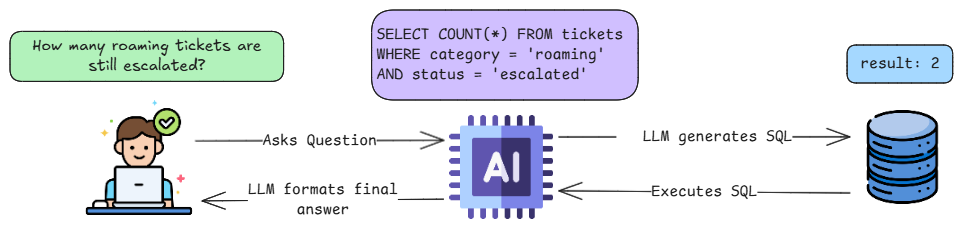

### **Explore the Database**

In [ ]:
import requests
import tempfile
import os
from langchain_community.utilities import SQLDatabase

# SQLite needs a local file — download tickets.db from GitHub
response = requests.get(TICKETS_URL)
response.raise_for_status()

# Write to a temp file that persists for the notebook session
db_path = os.path.join(tempfile.gettempdir(), "tickets.db")
with open(db_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded tickets.db → {db_path}")

Downloaded tickets.db → /var/folders/cv/zm85ty513pn29zxp2p8zsv8m0000gn/T/tickets.db


In [ ]:
db = SQLDatabase.from_uri(f"sqlite:///{db_path}")

print("Tables:", db.get_usable_table_names())
print("\nSchema:")
print(db.get_table_info())

Tables: ['tickets']

Schema:

CREATE TABLE tickets (
	id INTEGER, 
	ticket_id TEXT NOT NULL, 
	category TEXT NOT NULL, 
	issue_type TEXT NOT NULL, 
	description TEXT NOT NULL, 
	resolution TEXT NOT NULL, 
	status TEXT DEFAULT 'resolved' NOT NULL, 
	PRIMARY KEY (id), 
	UNIQUE (ticket_id)
)

/*
3 rows from tickets table:
id	ticket_id	category	issue_type	description	resolution	status
1	TK-001	connectivity	No internet access	Customer reports complete loss of mobile internet after switching from 3G to 4G mode.	Guided customer to toggle airplane mode and reset APN settings. Internet restored after APN was rese	resolved
2	TK-002	connectivity	Intermittent signal drops	Customer in a suburban area experiences signal dropping to zero several times per day, affecting bot	Network team identified a faulty sector antenna on the nearest tower. Temporary fix applied remotely	resolved
3	TK-003	data	Data balance not updating	Customer purchased a 5 GB add-on pack but the balance still shows the old figure

Let's see a few sample rows

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(db_path)
df_tickets = pd.read_sql("SELECT * FROM tickets LIMIT 5", conn)
conn.close()

print(f"Columns: {list(df_tickets.columns)}")
print(f"\nSample rows:")
df_tickets[["ticket_id", "category", "issue_type", "status"]].head(5)

Columns: ['id', 'ticket_id', 'category', 'issue_type', 'description', 'resolution', 'status']

Sample rows:


,ticket_id,category,issue_type,status
0,TK-001,connectivity,No internet access,resolved
1,TK-002,connectivity,Intermittent signal drops,resolved
2,TK-003,data,Data balance not updating,resolved
3,TK-004,roaming,Unexpected roaming charges,resolved
4,TK-005,sim,SIM card not recognised after phone update,resolved


# **Quick stats**

In [ ]:
conn = sqlite3.connect(db_path)
stats = pd.read_sql("""
    SELECT category, status, COUNT(*) as count
    FROM tickets
    GROUP BY category, status
    ORDER BY category
""", conn)
conn.close()
print(stats)

       category     status  count
0       account  escalated      1
1       account   resolved      1
2       billing   resolved      3
3  connectivity   resolved      4
4          data   resolved      3
5        device   resolved      1
6       roaming   resolved      2
7           sim   resolved      3
8         voice   resolved      2


### **Build the SQL QA Chain**

In [ ]:
import re

def clean_sql(raw: str) -> str:
    """Strip markdown fences and any preamble, leaving only the SQL statement."""
    raw = re.sub(r"```(?:sql)?", "", raw).strip("`").strip()
    # If the LLM prefixed with 'SQLQuery:' or 'Question: ...\nSQLQuery:', keep only what's after
    if "SQLQuery:" in raw:
        raw = raw.split("SQLQuery:")[-1].strip()
    return raw

In [ ]:
from langchain_classic.chains import create_sql_query_chain
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import ChatPromptTemplate


sql_query_chain = create_sql_query_chain(llm, db)

In [ ]:
SYSTEM_PROMPT = """You are a TelecomCo support analytics assistant.
Given a user question and the SQL query result from our tickets database,
provide a clear, concise natural language answer.
Be specific with numbers and facts from the data."""

In [ ]:
def sql_rag_chain(question: str) -> str:
    # Step 1: Generate SQL from the natural language question
    raw_sql = sql_query_chain.invoke({"question": question})
    sql = clean_sql(raw_sql)
    print(f"[debug] cleaned SQL → {sql}")

    # Step 2: Execute the SQL against the database
    result = db.run(sql)

    # Step 3: Ask the LLM to turn the raw result into a natural language answer
    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", "Question: {question}\nSQL Result: {result}\n\nAnswer:"),
    ])
    response = answer_prompt | llm
    return response.invoke({"question": question, "result": result}).content

print("✅ sql_rag_chain function ready")

✅ sql_rag_chain function ready


In [ ]:
def ask_sql(question: str):
    print(f"Question: {question}")
    answer = sql_rag_chain(question)
    print(f"Answer:   {answer}")
    print("-" * 60)

ask_sql("How many tickets are in each category?")

Question: How many tickets are in each category?
[debug] cleaned SQL → SELECT "category", COUNT(*) AS ticket_count
FROM tickets
GROUP BY "category"
LIMIT 5;
Answer:   There are 2 tickets in the **account** category, 3 in **billing**, 4 in **connectivity**, 3 in **data**, and 1 in **device**.
------------------------------------------------------------


In [ ]:
ask_sql("What is the most common issue type in the connectivity category?")

Question: What is the most common issue type in the connectivity category?
[debug] cleaned SQL → 
Answer:   I’m sorry, but I don’t have the query results to reference. Could you please provide the SQL output so I can give you an accurate answer?
------------------------------------------------------------


In [ ]:
ask_sql("How many tickets have been resolved vs escalated?")

Question: How many tickets have been resolved vs escalated?
[debug] cleaned SQL → SELECT "status", COUNT(*) AS "count"
FROM tickets
GROUP BY "status"
LIMIT 5;
Answer:   There are 19 tickets that have been resolved and only 1 ticket that has been escalated.
------------------------------------------------------------
